In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
#Load returns
PROCESSED_DIR = Path("../data/processed")
returns = pd.read_csv(PROCESSED_DIR / "returns_daily.csv", index_col="Date", parse_dates=True)

In [3]:
#Set parameters
TRADING_DAYS = 252
RF = 0.03
CAP = 0.40
N_PORT = 25000
SEED = 7

In [4]:
#Simulation Function w/ cap filter
def simulate_portfolios(mu, cov, n_portfolios=25000, rf=0.03, seed=7):
    np.random.seed(seed)
    tickers = mu.index.tolist()
    n_assets = len(tickers)
    weights = np.random.dirichlet(np.ones(n_assets), size=n_portfolios)

    port_ret = weights @ mu.values
    port_var = np.einsum('ij,jk,ik->i', weights, cov.values, weights)
    port_vol = np.sqrt(port_var)

    sharpe = (port_ret - rf) / np.where(port_vol == 0, np.nan, port_vol)

    sim = pd.DataFrame(weights, columns=[f"w_{t}" for t in tickers])
    sim["exp_return"] = port_ret
    sim["volatility"] = port_vol
    sim["sharpe"] = sharpe
    return sim

def apply_cap(sim_df, cap=0.40):
    wcols = [c for c in sim_df.columns if c.startswith("w_")]
    return sim_df[(sim_df[wcols] <= cap).all(axis=1)].copy()

def window_inputs(r):
    mu = r.mean() * TRADING_DAYS
    cov = r.cov() * TRADING_DAYS
    return mu, cov

In [5]:
#Define three regimes
REGIMES = {
    "Pre-COVID (2017–2019)": ("2017-01-01", "2019-12-31"),
    "COVID Shock (2020 H1)": ("2020-02-15", "2020-06-30"),
    "Post-COVID (2021–2024)": ("2021-01-01", "2024-12-31"),
}

In [6]:
#Run regime simulations & store outputs
results = {}

for label, (start, end) in REGIMES.items():
    r_win = returns.loc[start:end].dropna()
    mu, cov = window_inputs(r_win)

    sim = simulate_portfolios(mu, cov, n_portfolios=N_PORT, rf=RF, seed=SEED)
    sim_c = apply_cap(sim, cap=CAP)

    max_sharpe = sim_c.loc[sim_c["sharpe"].idxmax()]
    min_vol = sim_c.loc[sim_c["volatility"].idxmin()]

    results[label] = {
        "sim": sim_c,
        "max_sharpe": max_sharpe,
        "min_vol": min_vol,
        "window_rows": len(r_win)
    }

{k: v["window_rows"] for k, v in results.items()}

{'Pre-COVID (2017–2019)': 754,
 'COVID Shock (2020 H1)': 94,
 'Post-COVID (2021–2024)': 1004}

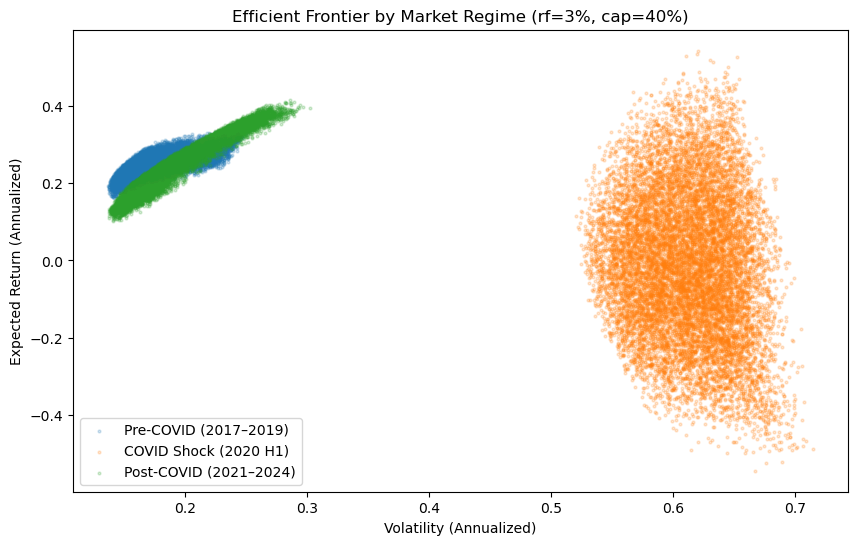

<Figure size 640x480 with 0 Axes>

In [12]:
#Frontiers overlay
plt.figure(figsize=(10,6))

for label, obj in results.items():
    sim = obj["sim"]
    plt.scatter(sim["volatility"], sim["exp_return"], s=4, alpha=0.20, label=label)

plt.xlabel("Volatility (Annualized)")
plt.ylabel("Expected Return (Annualized)")
plt.title("Efficient Frontier by Market Regime (rf=3%, cap=40%)")
plt.legend()
plt.show()

# Save to the relative path
# '../' goes up to 'project/', then into 'reports/figures/'
plt.savefig('../reports/figures/frontier_by_regime.png', dpi=300, bbox_inches='tight')

In [13]:
#Decision table
def extract_weights(row, tickers):
    return pd.Series({t: row[f"w_{t}"] for t in tickers}).sort_values(ascending=False)

tickers = returns.columns.tolist()

rows = []
for label, obj in results.items():
    ms = obj["max_sharpe"]
    mv = obj["min_vol"]
    rows.append({
        "Regime": label,
        "MaxSharpe_Return": ms["exp_return"],
        "MaxSharpe_Vol": ms["volatility"],
        "MaxSharpe_Sharpe": ms["sharpe"],
        "MinVol_Return": mv["exp_return"],
        "MinVol_Vol": mv["volatility"],
        "MinVol_Sharpe": mv["sharpe"],
    })

regime_summary = pd.DataFrame(rows).set_index("Regime")
regime_summary

# index=False prevents pandas from adding an extra column for row numbers
regime_summary.to_csv('../reports/figures/regime_summary.csv', index=False)

In [14]:
#weight change
weights_by_regime = {}
for label, obj in results.items():
    weights_by_regime[label] = extract_weights(obj["max_sharpe"], tickers)

weights_df = pd.DataFrame(weights_by_regime).T
weights_df

# index=False prevents pandas from adding an extra column for row numbers
weights_df.to_csv('../reports/figures/weights_df.csv', index=False)